In [1]:
import sys

sys.path.insert(1,"../src/")

from utilities import find_peaks, wideband_pulse
import warping

In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.ndimage import label

from scipy.special import softmax

In [3]:
from visualization_tools import SelectFromCollection

In [4]:
from sklearn.mixture import GaussianMixture

In [5]:
from skimage.filters import apply_hysteresis_threshold

In [6]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [7]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

NPERSEG = 80

NPEAKS = 20

In [234]:
wb_pulse_params = dict(pulse_duration=0.2, fs=SAMPLING_FREQ, bw=200, fc=350, window=sp.windows.tukey)

In [235]:
data1 = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = data1['f'].squeeze()
c = data1['soundspeed'].squeeze()
Vg = data1['Vg'][:,:,c == TRUE_SOUNDSPEED,...].squeeze()
source_range = data1['range'][0,0]

In [236]:
df = f[1] - f[0]

#t0 = 0
t0 = source_range*1e3/1500
N = SAMPLING_FREQ/df

In [237]:
X = data1["g"][1, data1["soundspeed"]==TRUE_SOUNDSPEED].squeeze()

In [238]:
X = X  * np.exp(1j*2*np.pi*f*t0);
# x = np.real(np.ifft(X,N) * exp(1i*2*pi*(0:N-1)'*f(1)/SAMPLING_FREQ);

x = np.real(np.fft.ifft(X,int(N)) * np.exp(1j*2*np.pi*np.arange(N)*f[0]/SAMPLING_FREQ))
tx = np.arange(N)/SAMPLING_FREQ + t0

In [239]:
h = wideband_pulse(**wb_pulse_params)

#x = sp.filtfilt(h, 1, x)

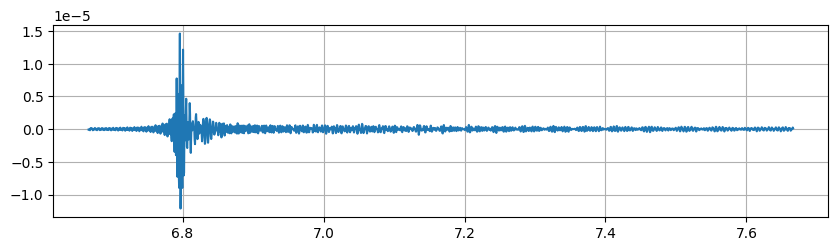

In [240]:
fig, ax = plt.subplots()
ax.plot(tx, x)

ax.grid()

fig.set_size_inches([10, 2.5])

## Spectrogram Compared to Mode Curves

In [241]:
[w, t, X] = sp.spectrogram(x, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG-1, 2000)
t = t + t0

w = w[201:502]
X = X[201:502, :]

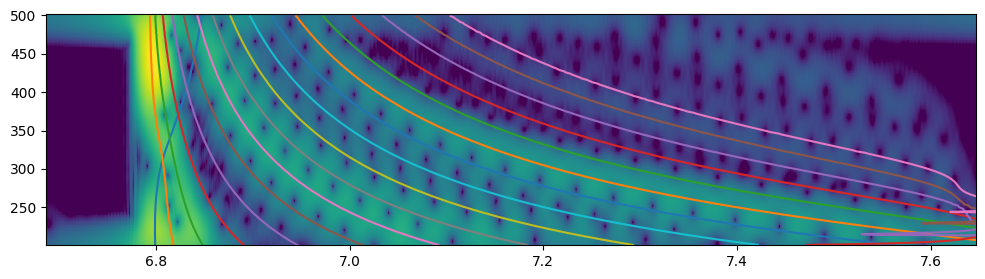

In [242]:
fig, ax = plt.subplots()
[low, high] = np.quantile(10*np.log10(X), [1e-1, 1])

ax.pcolormesh(t, w, 10*np.log10(X), vmin=low, vmax=high)

ax.plot(source_range*1e3/Vg.T, f[1:-1])
ax.set_xlim(t[[0, -1]])

fig.set_size_inches([12,3])


## Warping

In [243]:
origin_time = 6.8

x_warped, tw, fsw = warping.nonlinear_warping(x[tx>=origin_time], SAMPLING_FREQ, t0)

In [652]:
nperseg = 1000
nfft = 4000
[ww, txw, Xw] = sp.stft(x_warped, fsw, 'hamm', nperseg, nperseg-1, nfft)

Xw = Xw[ww<200, :]
ww = ww[ww<=200]

In [653]:
normalize01 = lambda x: (x-x.min())/(x.max() - x.min())
logistic = lambda x,c,sigma: 1/(1+np.exp(-(x-c)/sigma))

normpdf = lambda x, m, sigma: np.exp(-(x-m)**2/2/sigma**2)/sigma/np.sqrt(2*np.pi)

In [654]:
plt.hist

<function matplotlib.pyplot.hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, *, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'>

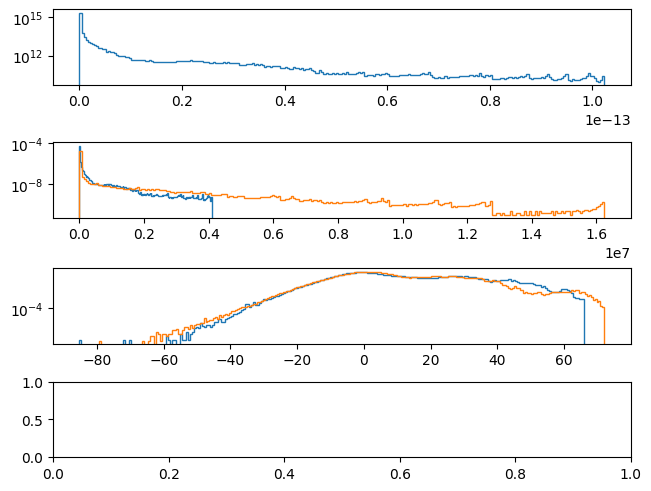

In [680]:
fig, ax = plt.subplots(4,1, layout="constrained")

kwargs = dict(bins = 256, density=True, histtype="step")

q = .3
u = np.abs(Xw)**2
un = u/np.quantile(u,q)
un_fwise = u/np.quantile(u, q, 1)[:, np.newaxis]

[n, b, p] = ax[0].hist(u.flat, **kwargs)
ax[0].set_yscale("log")

ax[1].hist(un.flat, **kwargs)
ax[1].set_yscale("log")

ax[1].hist(un_fwise.flat, **kwargs)
ax[1].set_yscale("log")

ax[2].hist(10*np.log10(un.flat), **kwargs)
ax[2].hist(10*np.log10(un_fwise.flat), **kwargs)
ax[2].set_yscale("log")


plt.show()


In [681]:
gaussian2d = lambda x, mx, sx, y, my, sy: np.exp(-((x - mx)**2/2/sx**2 + (y - my)**2/2/sy**2) )

MM, NN = np.meshgrid(range(1000), range(5))

HH = gaussian2d(MM, 500, 500, NN, 2, 1)

HH = HH/HH.sum()

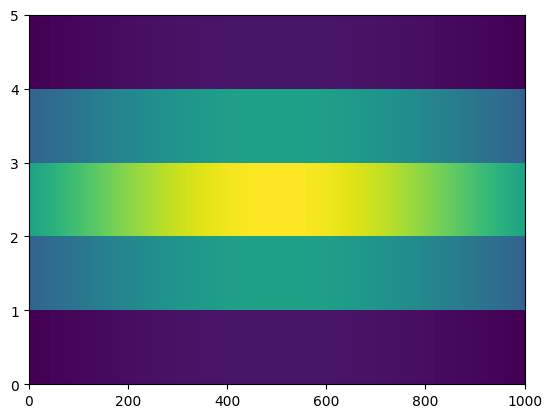

In [682]:
plt.pcolormesh(HH)

In [709]:
# working_data = 10*np.log10(sp.convolve2d(un_fwise, HH, 'same'))
working_data = 10*np.log10(un_fwise)

In [710]:
thresh = (30, 50)
mask = working_data > thresh[0]
maskhigh = working_data > thresh[1]
mask_histeresis = apply_hysteresis_threshold(working_data, *thresh) 

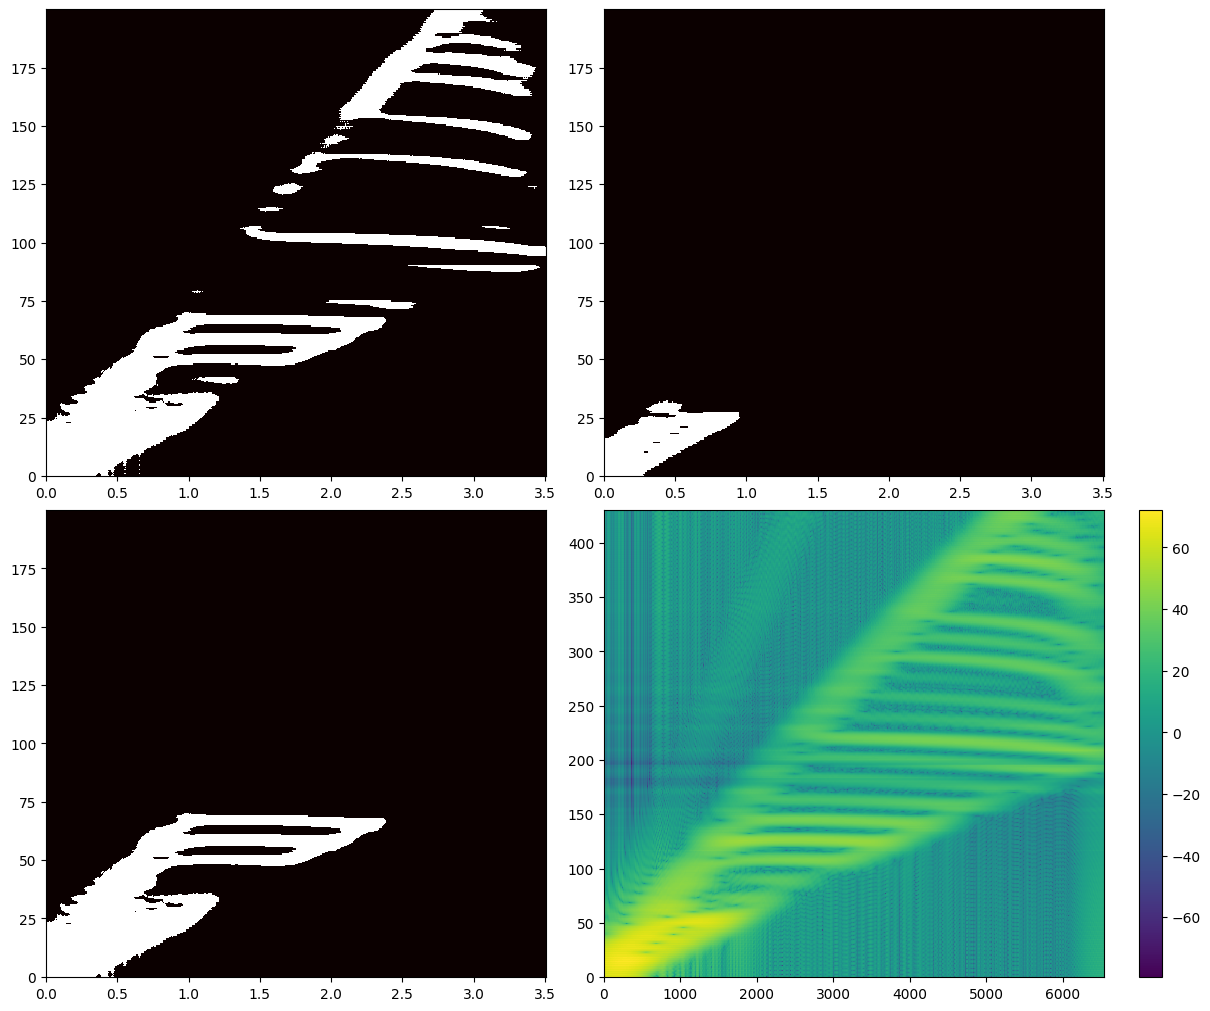

In [711]:
fig, [[ax, axhigh], [ax_histeresis, ax_data]] = plt.subplots(2,2,layout="constrained")

#ax_data.pcolormesh((np.arange(len(txw))+1)/len(txw), ww, np.sort(10*np.log10(working_data), 1))
m1 = ax_data.pcolormesh(working_data)

# ax_data.hlines(ww[p], txw[0], txw[-1])

plt.colorbar(m1, ax=ax_data)

ax.pcolormesh(txw, ww, mask, cmap="hot")
axhigh.pcolormesh(txw, ww, maskhigh, cmap="hot")

ax_histeresis.pcolormesh(txw, ww, mask_histeresis, cmap="hot")


fig.set_size_inches([12,10])
plt.show()

In [550]:
Xw_masked = Xw*mask_histeresis

ValueError: operands could not be broadcast together with shapes (215,410) (215,3) 

In [ ]:
labeled_data, nlabels = label(Xw_bool)

In [ ]:
fig, (ax, axbool, axl) = plt.subplots(1,3, layout='constrained')

ax.pcolormesh(txw, ww, Xw_log)

ax.set_ylim([0, 200])

ax.set_title("Warped Spectrogram")

axbool.pcolormesh(txw, ww, Xw_bool, cmap="hot")
axbool.set_ylim([0, 200])
axbool.set_title("Identified Regions")


axl.pcolormesh(txw, ww, labeled_data, cmap='turbo')
axl.set_ylim([0, 200])
axl.set_title("Labeled Regions")

fig.set_size_inches([12,4])

#fig.savefig('../data/output/figures/timewarping_labeled.png', dpi=600)

## Unwarping 

In [95]:
x_components = np.empty((nlabels, np.int64(N)))

for i_label in range(nlabels):
    mask_now = labeled_data == i_label
    X_comp_now = Xw * mask_now

    xnow = sp.istft(X_comp_now, fsw, 'hamm', nperseg, nperseg-1, nfft)[1]

    x_components[i_label] = warping.inv_nonlinear_warping(xnow, fsw, origin_time, SAMPLING_FREQ, N)[0]

[wc, tc, X_components] = sp.stft(x_components, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG - 1, 2000)

fmask = np.all([wc>=200, wc<=500], 0) 
wc = wc[fmask]    
X_components = X_components[:, fmask, :]


Text(0.02, 0.5, 'Frequency (Hz)')

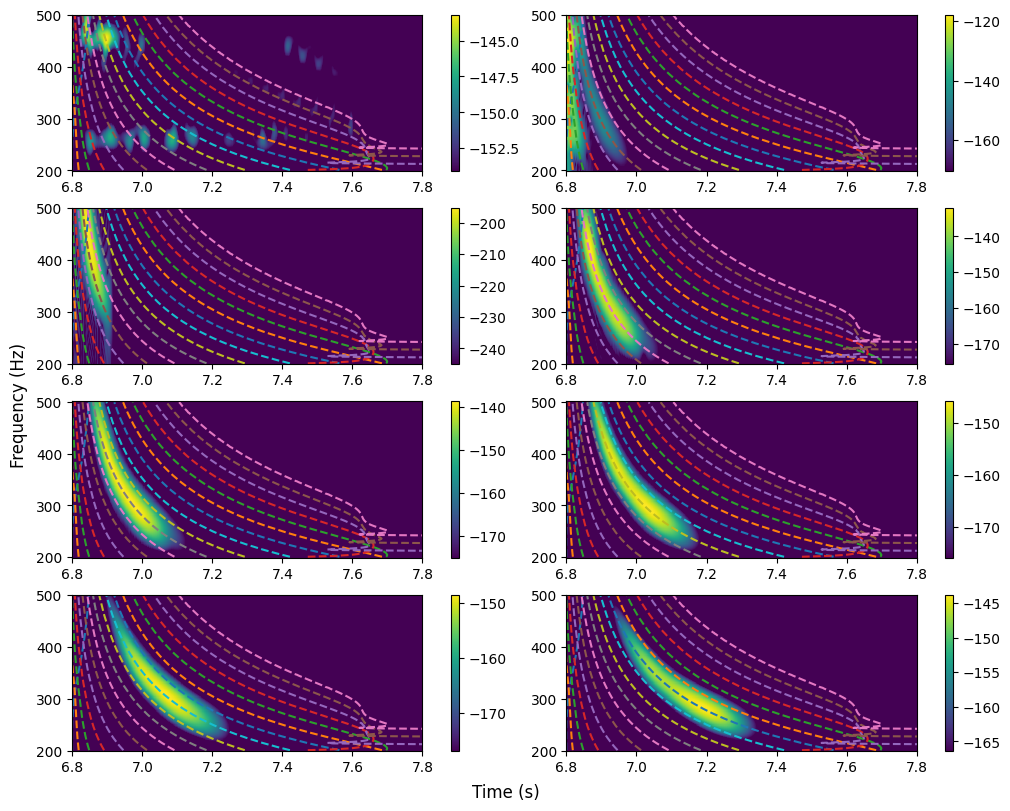

In [96]:
fig = plt.figure(layout='constrained')

vmin, vmax = np.quantile(20*np.log10(np.abs(X_components)), [.9, 1], [1,2])


nc = 2
nr = int(np.ceil(nlabels/2))

for ind in range(nlabels):
    ax = fig.add_subplot(nr, 2, ind + 1)
    m = ax.pcolormesh(tc + origin_time, wc, 20*np.log10(np.abs(X_components[ind])), vmin=vmin[ind], vmax=vmax[ind])
    ax.plot(source_range*1e3/Vg.T, f[1:-1], '--')
    ax.set_xlim(tc[[0,-1]] + origin_time)

    plt.colorbar(m, ax=ax)
fig.set_size_inches([10,8])    
fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')
#fig.savefig('../data/output/figures/timewarping_extracted_components.png', dpi=600)


In [97]:
peaks_components = list()

min_height = np.quantile(np.abs(X_components)**2, .95, [1,2])

for ind, Xc in enumerate(np.abs(X_components)**2):
    peaks_components.append(find_peaks(Xc, wc, tc + origin_time, npeaks=1, min_height = min_height[ind]))


Text(0.5, 0.98, 'Arrival times from unwarped data')

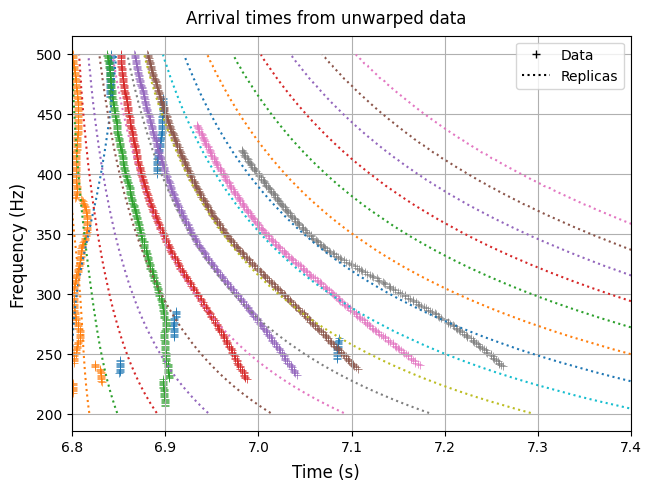

In [98]:
fig, ax = plt.subplots(layout='constrained')

ax.grid()
for p in peaks_components:
    ax.scatter(p[:,0], p[:,1], marker = '+', linewidths=.5)
ax.plot(source_range*1e3/Vg.T, f[1:-1], ':')
ax.set_xlim([origin_time, 7.4])

ax.plot(0, 350, 'k+', label="Data")
ax.plot(0, 350, 'k:', label="Replicas")

ax.legend()


fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')

fig.suptitle("Arrival times from unwarped data")
#fig.set_size_inches([30,12])    

#fig.savefig('../data/output/figures/timewarping_arrival_times.png', dpi=600)

In [67]:
export = {'peaks_coordinates':np.array(peaks_components[5:], dtype=object), 'mode_nos':np.array([9,10,11,12])}

np.savez('../data/output/warping_arrival_times.npz', **export)